In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [76]:
df=pd.read_csv("diabetes.csv")

In [77]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [78]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [79]:
cols = ['Glucose','BMI','BloodPressure','SkinThickness','Insulin']
df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

<Axes: >

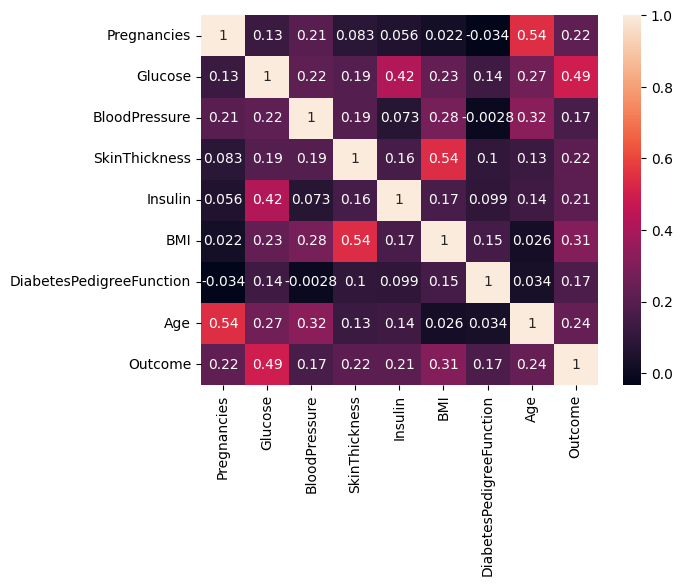

In [80]:
sns.heatmap(df.corr(),annot=True)

In [81]:
X=df.copy()
X.drop("Outcome",inplace=True,axis=1)

In [82]:
y=df["Outcome"]

In [83]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [84]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [85]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors =3)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [86]:
y_pred=classifier.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))



0.7207792207792207
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       100
           1       0.60      0.59      0.60        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154

[[79 21]
 [22 32]]


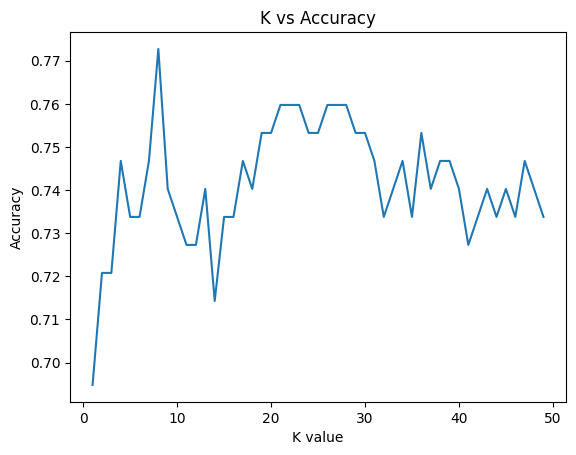

In [88]:
import matplotlib.pyplot as plt

k_values = range(1, 50)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.plot(k_values, accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

In [89]:
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 8
Best Accuracy: 0.7727272727272727


In [90]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors =best_k)
classifier.fit(X_train, y_train)
y_pred=classifier.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))



0.7727272727272727
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       100
           1       0.71      0.59      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154

[[87 13]
 [22 32]]
